In [3]:

# ==========================================
# 0. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import random


In [4]:

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
SMS_FILE = '/content/SMSSpamCollection'
DICT_FILE = '/content/10000 words.txt'

print("--- SYSTEM STARTUP ---")
print(f"Loading {SMS_FILE}...")

try:
    df = pd.read_csv(SMS_FILE, sep='\t', header=None, names=['label', 'message'])
    print(f"Loaded {len(df)} messages.")
except FileNotFoundError:
    raise FileNotFoundError("Please upload SMSSpamCollection to Colab.")

print(f"Loading {DICT_FILE}...")
try:
    with open(DICT_FILE, 'r') as f:
        dictionary_words = [line.strip() for line in f if line.strip()]
    print(f"Loaded {len(dictionary_words)} dictionary words.")
except FileNotFoundError:
    print("Dictionary file not found. Using dummy words.")
    dictionary_words = ["apple", "banana", "cherry", "date", "elderberry"]


--- SYSTEM STARTUP ---
Loading /content/SMSSpamCollection...
Loaded 5572 messages.
Loading /content/10000 words.txt...
Loaded 10000 dictionary words.


In [5]:

# ==========================================
# 2. Data Preparation
# ==========================================
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['message'], df['label_num'], test_size=0.3, random_state=42
)

vectorizer = CountVectorizer(stop_words='english')
vectorizer.fit(X_train_raw)

X_test_vec = vectorizer.transform(X_test_raw)

print("Training and test data prepared.")


Training and test data prepared.


In [6]:

# ==========================================
# 3. User Input for Attack Scenarios
# ==========================================
print("\n" + "="*50)
print("CONFIGURE ATTACK SCENARIOS")
print("="*50)
print("Enter the number of attack emails to add for each test case.")
print("Separate numbers with commas (e.g., 0, 50, 100, 500)")

user_input = input("Enter attack counts: ")

try:
    attack_counts = [int(x.strip()) for x in user_input.split(',')]
    attack_counts = sorted(list(set(attack_counts)))
    if 0 not in attack_counts:
        attack_counts.insert(0, 0)
except ValueError:
    print("Invalid input! Using default sequence: [0, 50, 200, 500, 1000]")
    attack_counts = [0, 50, 200, 500, 1000]

print("Attack scenarios:", attack_counts)



CONFIGURE ATTACK SCENARIOS
Enter the number of attack emails to add for each test case.
Separate numbers with commas (e.g., 0, 50, 100, 500)
Enter attack counts: 50,100,500,1000,1500
Attack scenarios: [0, 50, 100, 500, 1000, 1500]


In [7]:

# ==========================================
# 4. Attack Execution, Training & Evaluation
# ==========================================
results = []

print("\n" + "="*60)
print(f"{'# Attack Emails':<15} | {'Acc.':<8} | {'F1':<8} | {'Prec.':<8} | {'Recall':<8}")
print("-" * 60)

for num_attack_emails in attack_counts:
    attack_messages = []
    for _ in range(num_attack_emails):
        msg = " ".join(random.choices(dictionary_words, k=50))
        attack_messages.append(msg)

    X_train_poisoned_raw = pd.concat([X_train_raw, pd.Series(attack_messages)])
    attack_labels = pd.Series([1] * num_attack_emails)
    y_train_poisoned = pd.concat([y_train, attack_labels])

    X_train_poisoned_vec = vectorizer.transform(X_train_poisoned_raw)

    model = MultinomialNB()
    model.fit(X_train_poisoned_vec, y_train_poisoned)

    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)

    results.append((num_attack_emails, acc, f1))

    print(f"{num_attack_emails:<15} | {acc:.4f}   | {f1:.4f}   | {prec:.4f}   | {rec:.4f}")
    print(f"\n[Confusion Matrix for {num_attack_emails} attack emails]")
    print(f"True Ham: {cm[0][0]:<5}  False Ham (Missed Spam): {cm[1][0]}")
    print(f"False Spam: {cm[0][1]:<4}  True Spam: {cm[1][1]}")
    print("-" * 60)



# Attack Emails | Acc.     | F1       | Prec.    | Recall  
------------------------------------------------------------
0               | 0.9874   | 0.9729   | 0.9738   | 0.9720

[Confusion Matrix for 0 attack emails]
True Ham: 1438   False Ham (Missed Spam): 11
False Spam: 10    True Spam: 213
------------------------------------------------------------
50              | 0.9856   | 0.9692   | 0.9674   | 0.9710

[Confusion Matrix for 50 attack emails]
True Ham: 1435   False Ham (Missed Spam): 11
False Spam: 13    True Spam: 213
------------------------------------------------------------
100             | 0.9856   | 0.9692   | 0.9674   | 0.9710

[Confusion Matrix for 100 attack emails]
True Ham: 1435   False Ham (Missed Spam): 11
False Spam: 13    True Spam: 213
------------------------------------------------------------


/tmp/ipython-input-692248530.py:18: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  y_train_poisoned = pd.concat([y_train, attack_labels])


500             | 0.9767   | 0.9513   | 0.9381   | 0.9658

[Confusion Matrix for 500 attack emails]
True Ham: 1420   False Ham (Missed Spam): 11
False Spam: 28    True Spam: 213
------------------------------------------------------------
1000            | 0.9653   | 0.9299   | 0.9057   | 0.9592

[Confusion Matrix for 1000 attack emails]
True Ham: 1401   False Ham (Missed Spam): 11
False Spam: 47    True Spam: 213
------------------------------------------------------------
1500            | 0.9557   | 0.9133   | 0.8813   | 0.9556

[Confusion Matrix for 1500 attack emails]
True Ham: 1384   False Ham (Missed Spam): 10
False Spam: 64    True Spam: 214
------------------------------------------------------------


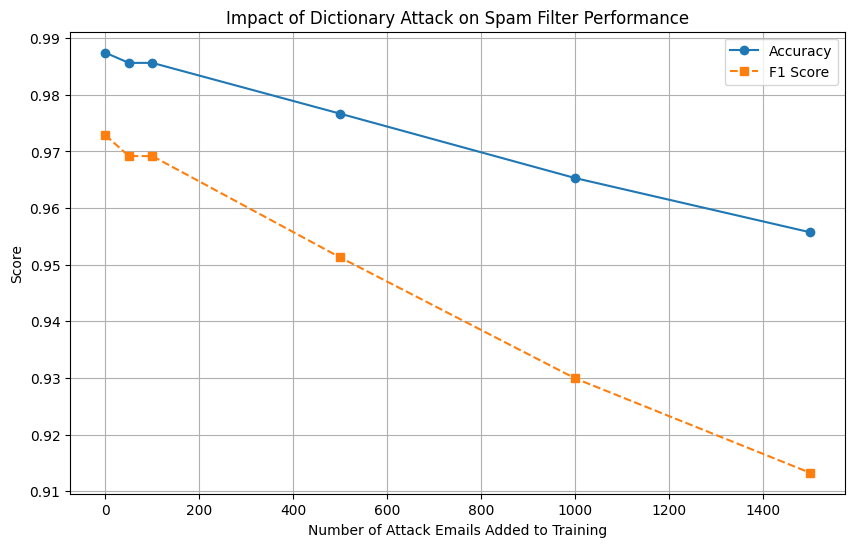

In [8]:

# ==========================================
# 5. Visualization
# ==========================================
attacks_x = [r[0] for r in results]
acc_y = [r[1] for r in results]
f1_y = [r[2] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(attacks_x, acc_y, marker='o', linestyle='-', label='Accuracy')
plt.plot(attacks_x, f1_y, marker='s', linestyle='--', label='F1 Score')

plt.title('Impact of Dictionary Attack on Spam Filter Performance')
plt.xlabel('Number of Attack Emails Added to Training')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()
